# LSTM Stock Price Prediction — AAPL

**Pipeline:**
1. Load 2yr OHLCV data via yfinance
2. Normalize with MinMaxScaler (per-feature)
3. Build 60-day lookback sequences
4. Train 2-layer LSTM (50 units each) with Dropout(0.2)
5. Evaluate: RMSE, MAE, MAPE
6. Save model to `../ml-service/saved_models/AAPL/model.h5`

**Kernel:** Python 3.11 venv at `notebooks/.venv_nb`

## 0 · Imports & Config

In [1]:
import warnings
warnings.filterwarnings('ignore')
import os, pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Config ──────────────────────────────────────────────────────────────────
TICKER        = 'AAPL'
PERIOD        = '2y'          # 2 years of daily bars
SEQ_LEN       = 60            # 60-day lookback window
FEATURES      = ['Open', 'High', 'Low', 'Close', 'Volume']
TARGET_IDX    = 3             # Close price is index 3 in FEATURES
TRAIN_SPLIT   = 0.80
EPOCHS        = 100
BATCH_SIZE    = 32
SAVE_DIR      = f'../ml-service/saved_models/{TICKER}'

os.makedirs(SAVE_DIR, exist_ok=True)

plt.style.use('dark_background')
sns.set_palette('husl')
print(f'TensorFlow {tf.__version__}  |  GPU available: {bool(tf.config.list_physical_devices("GPU"))}')

TensorFlow 2.15.1  |  GPU available: False


## 1 · Load 2-Year OHLCV Data

In [2]:
ticker_obj = yf.Ticker(TICKER)
df = ticker_obj.history(period=PERIOD, auto_adjust=True)
df = df[FEATURES].copy()
df.index = pd.to_datetime(df.index).tz_localize(None)
df.dropna(inplace=True)

print(f'Loaded {len(df)} trading days  ({df.index[0].date()} → {df.index[-1].date()})')
print(f'Columns: {list(df.columns)}')
df.tail(5)

Loaded 502 trading days  (2024-03-27 → 2026-03-27)
Columns: ['Open', 'High', 'Low', 'Close', 'Volume']


,Open,High,Low,Close,Volume
Date,,,,,
2026-03-23,253.970001,254.600006,250.279999,251.490005,40546100
2026-03-24,250.350006,254.830002,249.550003,251.639999,45152300
2026-03-25,254.100006,255.000000,251.600006,252.619995,28476700
2026-03-26,252.119995,257.000000,250.770004,252.889999,41796700
2026-03-27,253.910004,255.492996,248.330002,248.919998,29787017


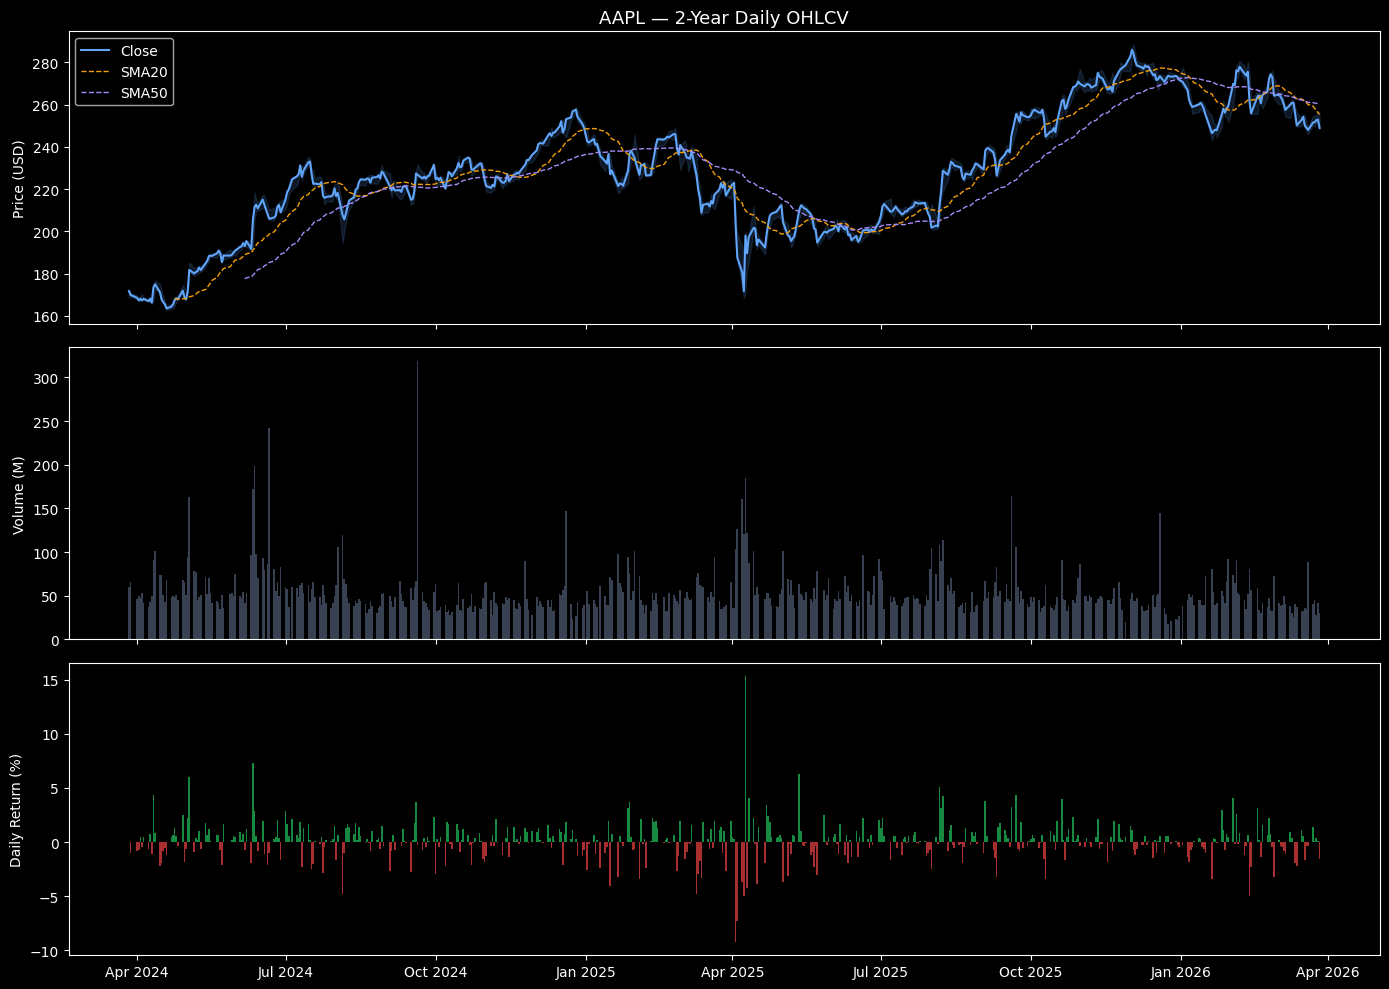


Close price stats:
count    502.00
mean     227.97
std       28.23
min      163.51
25%      209.68
50%      226.72
75%      249.52
max      285.92
Name: Close, dtype: float64


In [3]:
# ── Quick EDA ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['Close'], lw=1.5, color='#60a5fa', label='Close')
axes[0].fill_between(df.index, df['Low'], df['High'], alpha=0.15, color='#60a5fa')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title(f'{TICKER} — 2-Year Daily OHLCV', fontsize=13)
axes[0].legend()

# 20-day and 50-day SMA
axes[0].plot(df.index, df['Close'].rolling(20).mean(), lw=1, color='#f59e0b', label='SMA20', linestyle='--')
axes[0].plot(df.index, df['Close'].rolling(50).mean(), lw=1, color='#a78bfa', label='SMA50', linestyle='--')
axes[0].legend()

axes[1].bar(df.index, df['Volume'] / 1e6, color='#374151', width=1)
axes[1].set_ylabel('Volume (M)')

# Daily returns
returns = df['Close'].pct_change() * 100
axes[2].bar(df.index, returns, color=np.where(returns >= 0, '#22c55e', '#ef4444'), width=1, alpha=0.7)
axes[2].set_ylabel('Daily Return (%)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_ohlcv_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClose price stats:')
print(df['Close'].describe().round(2))

## 2 · Normalize with MinMaxScaler

In [4]:
# ── Split BEFORE scaling to prevent data leakage ─────────────────────────────
# Never fit the scaler on test data — that would leak future information
split_idx = int(len(df) * TRAIN_SPLIT)
train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

print(f'Train: {len(train_df)} rows  ({train_df.index[0].date()} → {train_df.index[-1].date()})')
print(f'Test:  {len(test_df)} rows  ({test_df.index[0].date()} → {test_df.index[-1].date()})')

# ── Fit scaler on TRAIN only ─────────────────────────────────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_df[FEATURES].values)
test_scaled  = scaler.transform(test_df[FEATURES].values)   # transform only

# Separate close-only scaler for inverse-transforming predictions
close_scaler = MinMaxScaler(feature_range=(0, 1))
close_scaler.fit(train_df[['Close']].values)

print(f'\nScaler fitted on training data only (no leakage)')
print(f'Feature range after scaling: [{train_scaled.min():.3f}, {train_scaled.max():.3f}]')

# Save scalers
with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(f'{SAVE_DIR}/close_scaler.pkl', 'wb') as f:
    pickle.dump(close_scaler, f)

print('Scalers saved.')

Train: 401 rows  (2024-03-27 → 2025-10-30)
Test:  101 rows  (2025-10-31 → 2026-03-27)

Scaler fitted on training data only (no leakage)
Feature range after scaling: [0.000, 1.000]
Scalers saved.


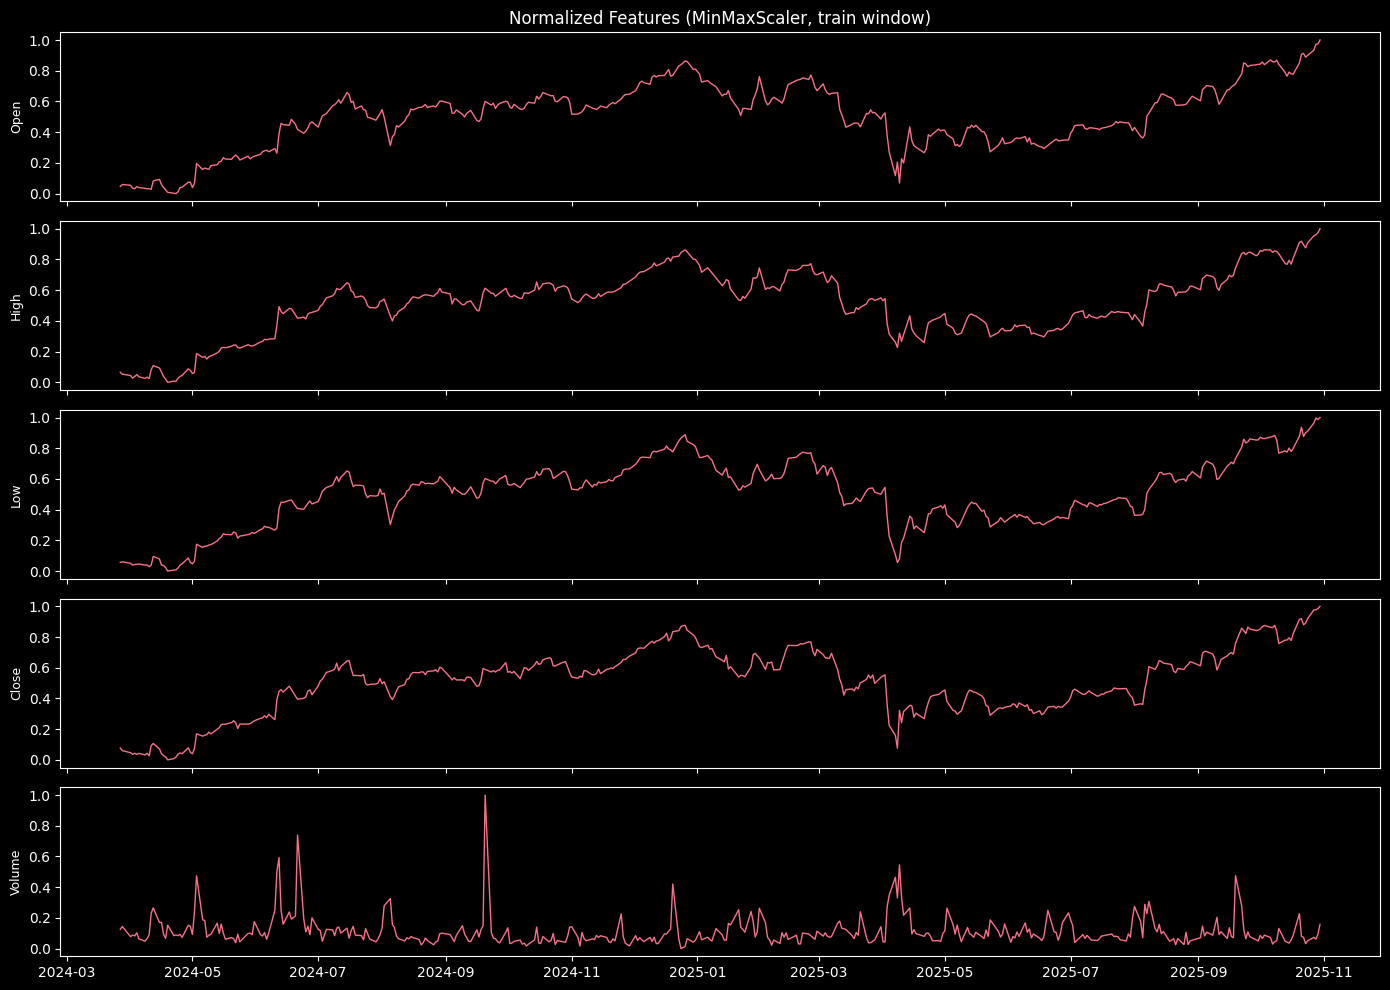

In [5]:
# ── Visualize normalized features ────────────────────────────────────────────
fig, axes = plt.subplots(len(FEATURES), 1, figsize=(14, 10), sharex=True)
for i, feat in enumerate(FEATURES):
    axes[i].plot(train_df.index, train_scaled[:, i], lw=1, label=f'{feat} (train)')
    axes[i].set_ylabel(feat, fontsize=9)
    axes[i].set_ylim(-0.05, 1.05)

axes[0].set_title('Normalized Features (MinMaxScaler, train window)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_normalized_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Build 60-Day Lookback Windows

In [6]:
def create_sequences(data: np.ndarray, seq_len: int, target_idx: int):
    """
    Sliding window: each sample is seq_len days of all features,
    target is the NEXT day's scaled close price.

    X shape: (n_samples, seq_len, n_features)
    y shape: (n_samples,)
    """
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len : i])     # 60 days of OHLCV
        y.append(data[i, target_idx])       # next-day close (scaled)
    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, SEQ_LEN, TARGET_IDX)
X_test,  y_test  = create_sequences(test_scaled,  SEQ_LEN, TARGET_IDX)

print(f'X_train shape: {X_train.shape}   → (samples, timesteps, features)')
print(f'y_train shape: {y_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print(f'y_test  shape: {y_test.shape}')
print(f'\nEach input: {SEQ_LEN} trading days × {len(FEATURES)} features')
print(f'Target:     next-day close price (scaled)')

X_train shape: (341, 60, 5)   → (samples, timesteps, features)
y_train shape: (341,)
X_test  shape: (41, 60, 5)
y_test  shape: (41,)

Each input: 60 trading days × 5 features
Target:     next-day close price (scaled)


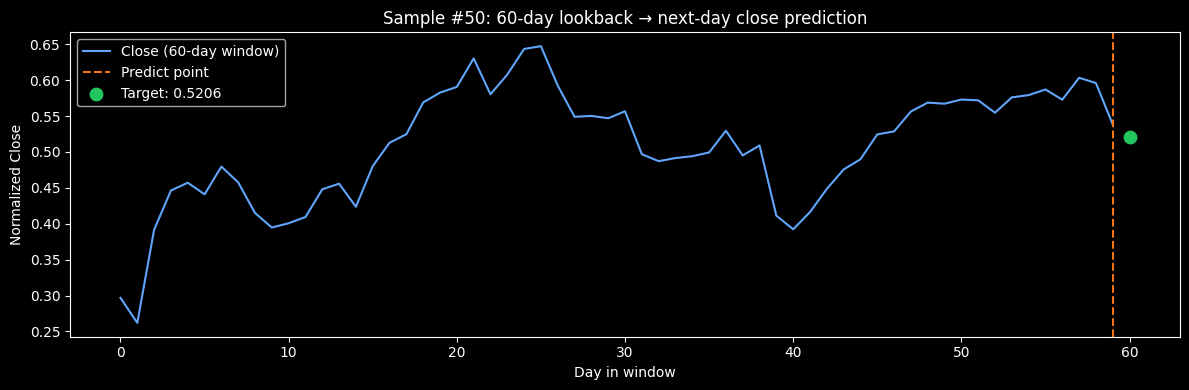

In [7]:
# ── Visualize a single sequence window ───────────────────────────────────────
sample_idx = 50
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(SEQ_LEN), X_train[sample_idx, :, TARGET_IDX],
        color='#60a5fa', lw=1.5, label='Close (60-day window)')
ax.axvline(SEQ_LEN - 1, color='#f97316', linestyle='--', lw=1.5, label='Predict point')
ax.scatter(SEQ_LEN, y_train[sample_idx], color='#22c55e', s=80, zorder=5, label=f'Target: {y_train[sample_idx]:.4f}')
ax.set_xlabel('Day in window')
ax.set_ylabel('Normalized Close')
ax.set_title(f'Sample #{sample_idx}: 60-day lookback → next-day close prediction')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_sequence_window.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 · Build LSTM Model

In [8]:
def build_model(seq_len: int, n_features: int) -> keras.Model:
    """
    2-layer stacked LSTM:
      - Layer 1: LSTM(50, return_sequences=True) + Dropout(0.2)
      - Layer 2: LSTM(50, return_sequences=False) + Dropout(0.2)
      - Output:  Dense(1)  — next-day close price

    Huber loss is used instead of MSE: less sensitive to outlier
    price spikes (earnings, splits) which would otherwise dominate gradients.
    """
    model = Sequential([
        Input(shape=(seq_len, n_features)),

        LSTM(50, return_sequences=True),
        Dropout(0.2),

        LSTM(50, return_sequences=False),
        Dropout(0.2),

        Dense(1)
    ], name='aapl_lstm')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='huber',
        metrics=['mae']
    )
    return model


model = build_model(SEQ_LEN, len(FEATURES))
model.summary()

Model: "aapl_lstm"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 lstm (LSTM)                 (None, 60, 50)            11200     


 dropout (Dropout)           (None, 60, 50)            0         


...

 dense (Dense)               (None, 1)                 51        


Total params: 31451 (122.86 KB)


Trainable params: 31451 (122.86 KB)


Non-trainable params: 0 (0.00 Byte)


_________________________________________________________________


In [9]:
# Count parameters
total   = model.count_params()
trainable = sum(v.numpy().size for v in model.trainable_variables)
print(f'Total parameters:     {total:,}')
print(f'Trainable parameters: {trainable:,}')

Total parameters:     31,451
Trainable parameters: 31,451


## 5 · Train on AAPL

In [10]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{SAVE_DIR}/model_best.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining complete — {len(history.history["loss"])} epochs run')

Epoch 1/100


 1/10 [==>...........................] - ETA: 26s - loss: 0.2256 - mae: 0.6454

 3/10 [========>.....................] - ETA: 0s - loss: 0.1927 - mae: 0.5987 

 5/10 [==============>...............] - ETA: 0s - loss: 0.1392 - mae: 0.4866

 7/10 [====================>.........] - ETA: 0s - loss: 0.1044 - mae: 0.3932

...

Restoring model weights from the end of the best epoch: 1.



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


10/10 [==============================] - 0s 33ms/step - loss: 0.0047 - mae: 0.0760 - val_loss: 0.0095 - val_mae: 0.1219 - lr: 5.0000e-04


Epoch 11: early stopping



Training complete — 11 epochs run


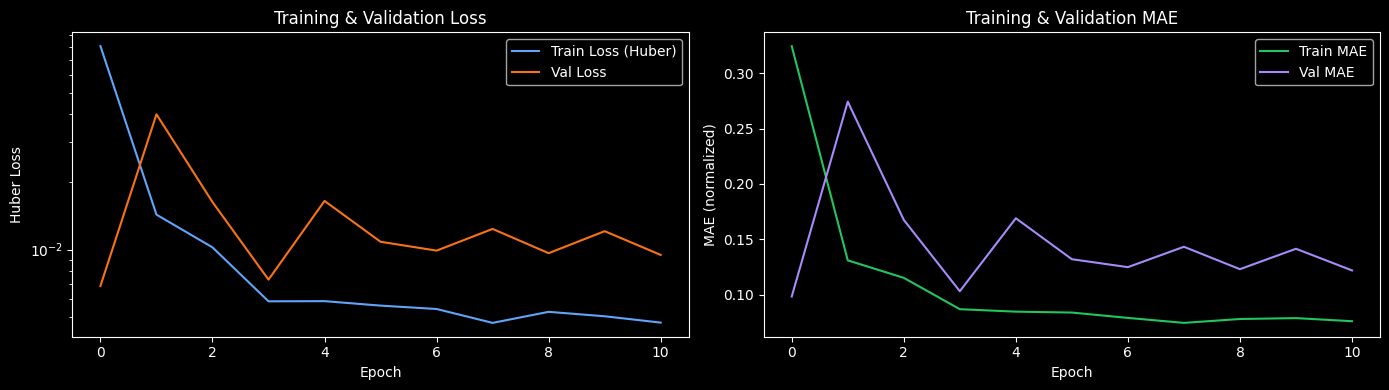

In [11]:
# ── Training curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss (Huber)', color='#60a5fa', lw=1.5)
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#f97316', lw=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].set_yscale('log')

axes[1].plot(history.history['mae'], label='Train MAE', color='#22c55e', lw=1.5)
axes[1].plot(history.history['val_mae'], label='Val MAE', color='#a78bfa', lw=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (normalized)')
axes[1].set_title('Training & Validation MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 · Evaluate — RMSE, MAE, MAPE

In [12]:
# ── Predict on test set ──────────────────────────────────────────────────────
y_pred_scaled = model.predict(X_test, verbose=0).flatten()

# Inverse-transform: reconstruct full 5-feature vector to use scaler.inverse_transform
def inverse_close(scaled_close: np.ndarray) -> np.ndarray:
    """Inverse-transform close-only predictions back to USD."""
    dummy = np.zeros((len(scaled_close), len(FEATURES)))
    dummy[:, TARGET_IDX] = scaled_close
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]

y_pred_usd  = inverse_close(y_pred_scaled)
y_actual_usd = inverse_close(y_test)

# ── Metrics ──────────────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_actual_usd, y_pred_usd))
mae  = mean_absolute_error(y_actual_usd, y_pred_usd)
mape = np.mean(np.abs((y_actual_usd - y_pred_usd) / (y_actual_usd + 1e-8))) * 100
r2   = 1 - np.sum((y_actual_usd - y_pred_usd)**2) / np.sum((y_actual_usd - y_actual_usd.mean())**2)

print('━' * 45)
print(f'  {TICKER} LSTM Test-Set Metrics')
print('━' * 45)
print(f'  RMSE : ${rmse:.4f}')
print(f'  MAE  : ${mae:.4f}')
print(f'  MAPE : {mape:.4f}%')
print(f'  R²   : {r2:.4f}')
print('━' * 45)
print(f'  Interpretation: on avg, predictions are')
print(f'  ${mae:.2f} off from actual closing price')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AAPL LSTM Test-Set Metrics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RMSE : $16.2353
  MAE  : $14.1906
  MAPE : 5.5215%
  R²   : -2.4388
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Interpretation: on avg, predictions are
  $14.19 off from actual closing price


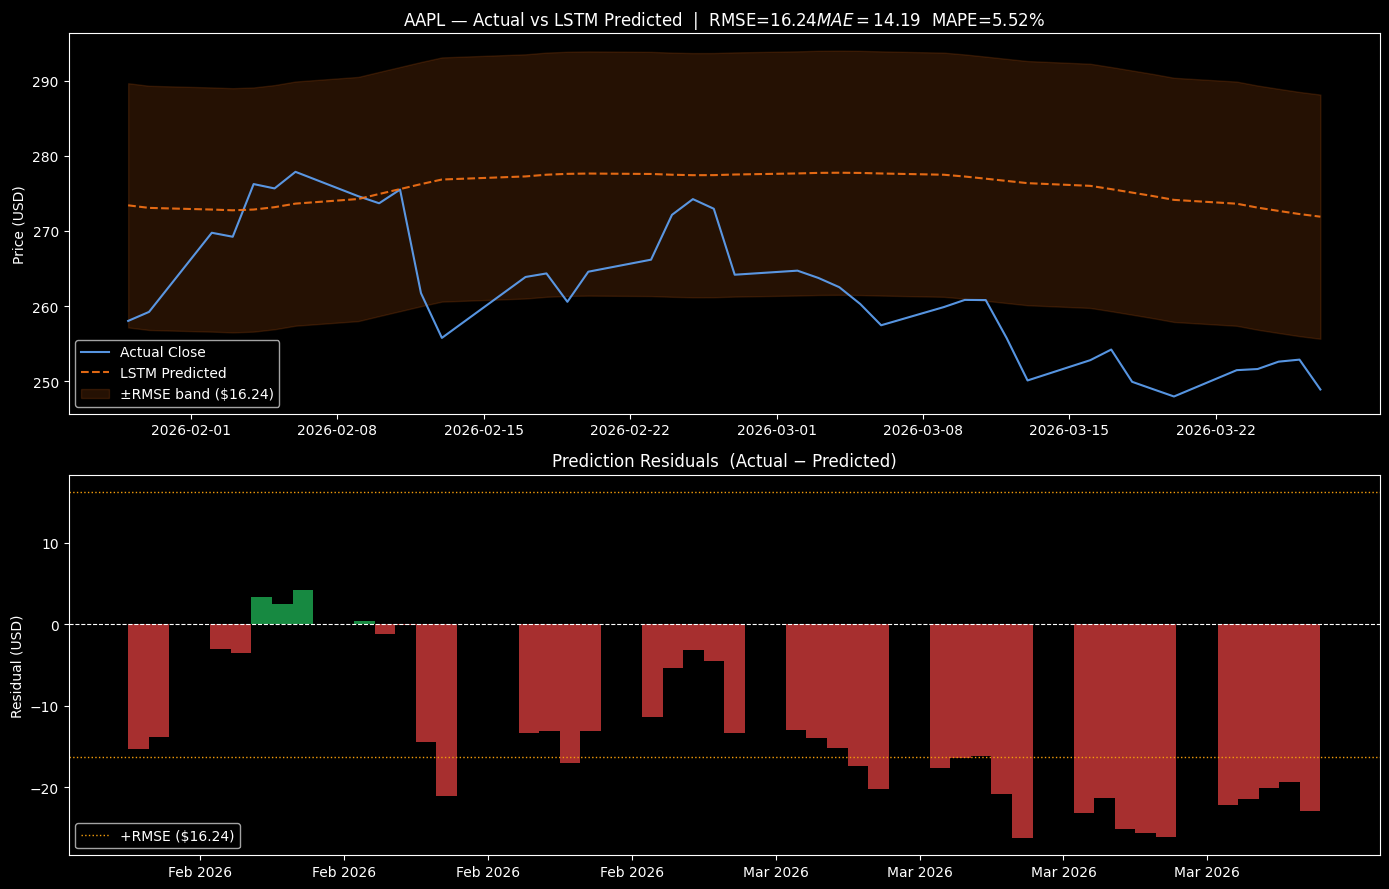

In [13]:
# ── Actual vs Predicted plot ─────────────────────────────────────────────────
test_dates = test_df.index[SEQ_LEN:]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Main prediction chart
axes[0].plot(test_dates, y_actual_usd, lw=1.5, color='#60a5fa', label='Actual Close', alpha=0.9)
axes[0].plot(test_dates, y_pred_usd,   lw=1.5, color='#f97316', label='LSTM Predicted', linestyle='--', alpha=0.9)
axes[0].fill_between(test_dates,
                     y_pred_usd - rmse, y_pred_usd + rmse,
                     alpha=0.15, color='#f97316', label=f'±RMSE band (${rmse:.2f})')
axes[0].set_ylabel('Price (USD)')
axes[0].set_title(f'{TICKER} — Actual vs LSTM Predicted  |  RMSE=${rmse:.2f}  MAE=${mae:.2f}  MAPE={mape:.2f}%')
axes[0].legend()

# Residuals
residuals = y_actual_usd - y_pred_usd
axes[1].bar(test_dates, residuals,
            color=np.where(residuals >= 0, '#22c55e', '#ef4444'),
            width=1, alpha=0.7)
axes[1].axhline(0, color='white', lw=0.8, linestyle='--')
axes[1].axhline(rmse, color='#f59e0b', lw=1, linestyle=':', label=f'+RMSE (${rmse:.2f})')
axes[1].axhline(-rmse, color='#f59e0b', lw=1, linestyle=':')
axes[1].set_ylabel('Residual (USD)')
axes[1].set_title('Prediction Residuals  (Actual − Predicted)')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

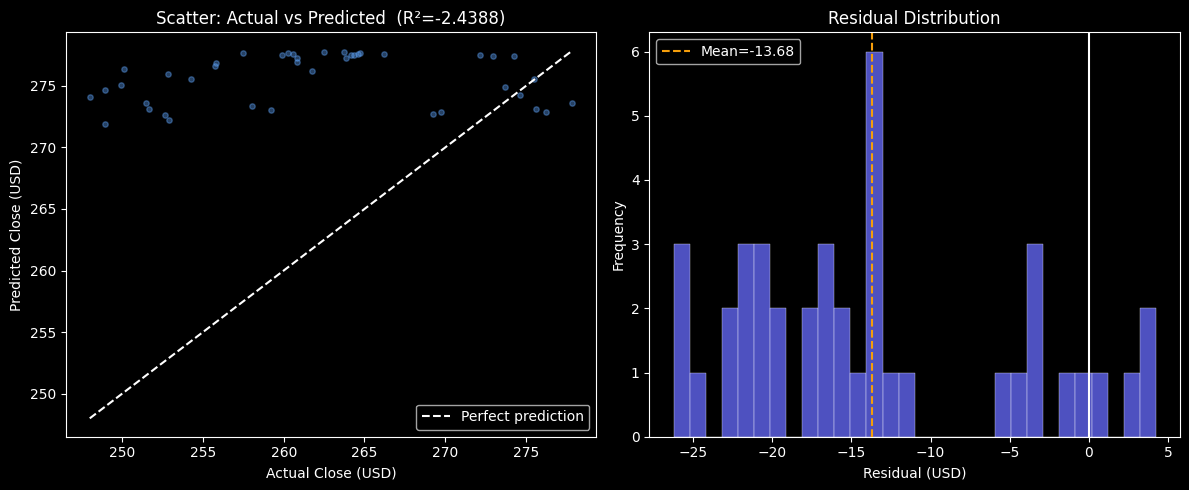

In [14]:
# ── Scatter: actual vs predicted ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_actual_usd, y_pred_usd, alpha=0.4, s=15, color='#60a5fa')
mn, mx = y_actual_usd.min(), y_actual_usd.max()
axes[0].plot([mn, mx], [mn, mx], 'w--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Close (USD)')
axes[0].set_ylabel('Predicted Close (USD)')
axes[0].set_title(f'Scatter: Actual vs Predicted  (R²={r2:.4f})')
axes[0].legend()

axes[1].hist(residuals, bins=30, color='#6366f1', alpha=0.8, edgecolor='white', lw=0.3)
axes[1].axvline(0, color='white', lw=1.5)
axes[1].axvline(residuals.mean(), color='#f59e0b', lw=1.5, linestyle='--',
                label=f'Mean={residuals.mean():.2f}')
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/06_scatter_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Save Model as .h5

In [15]:
# Save in both formats:
# - .h5   legacy format, max compatibility with older inference code
# - .keras native Keras format, recommended for new code
model.save(f'{SAVE_DIR}/model.h5')
model.save(f'{SAVE_DIR}/model.keras')

# Save metrics alongside model for the /predict endpoint to report back
import json
metrics = {
    'ticker': TICKER,
    'rmse': round(float(rmse), 4),
    'mae': round(float(mae), 4),
    'mape': round(float(mape), 4),
    'r2': round(float(r2), 4),
    'epochs_run': len(history.history['loss']),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'seq_len': SEQ_LEN,
    'features': FEATURES,
    'trained_at': pd.Timestamp.now().isoformat(),
}

with open(f'{SAVE_DIR}/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('Saved:')
for fname in ['model.h5', 'model.keras', 'scaler.pkl', 'close_scaler.pkl', 'metrics.json']:
    path = f'{SAVE_DIR}/{fname}'
    size_kb = os.path.getsize(path) / 1024
    print(f'  {fname:<22} {size_kb:>8.1f} KB')

print(f'\nAll artifacts in: {SAVE_DIR}/')

Saved:
  model.h5                  412.4 KB
  model.keras               404.5 KB
  scaler.pkl                  0.7 KB
  close_scaler.pkl            0.5 KB
  metrics.json                0.3 KB

All artifacts in: ../ml-service/saved_models/AAPL/


## 8 · 30-Day Forward Forecast

In [16]:
# ── Recursive multi-step forecasting ─────────────────────────────────────────
# Seed with the last SEQ_LEN days of known data
full_scaled = scaler.transform(df[FEATURES].values)
window = full_scaled[-SEQ_LEN:].copy()   # shape (60, 5)

forecast_days = 30
raw_forecast  = []

for _ in range(forecast_days):
    X_in = window.reshape(1, SEQ_LEN, len(FEATURES))
    next_close_scaled = model.predict(X_in, verbose=0)[0, 0]
    raw_forecast.append(next_close_scaled)
    # Shift window: drop oldest row, append new row with predicted close
    new_row = window[-1].copy()
    new_row[TARGET_IDX] = next_close_scaled
    window = np.vstack([window[1:], new_row])

forecast_prices = inverse_close(np.array(raw_forecast))

# Build confidence interval from test residuals
std = float(np.std(residuals))
ci  = 1.96 * std   # 95%

# Business day dates
from datetime import timedelta
last_date = df.index[-1]
forecast_dates = pd.bdate_range(start=last_date + timedelta(days=1), periods=forecast_days)

forecast_df = pd.DataFrame({
    'date':  forecast_dates,
    'price': forecast_prices,
    'lower': forecast_prices - ci,
    'upper': forecast_prices + ci,
})

print(f'30-day forecast (from {forecast_dates[0].date()} to {forecast_dates[-1].date()})')
print(f'95% CI width: ±${ci:.2f}')
forecast_df.head(10)

30-day forecast (from 2026-03-30 to 2026-05-08)
95% CI width: ±$17.14


,date,price,lower,upper
0,2026-03-30,271.563409,254.424749,288.702069
1,2026-03-31,271.239371,254.100711,288.378031
2,2026-04-01,271.046979,253.908319,288.185639
3,2026-04-02,270.937234,253.798574,288.075894
4,2026-04-03,270.895737,253.757077,288.034397
5,2026-04-06,270.906822,253.768162,288.045482
6,2026-04-07,270.957061,253.818401,288.095721
7,2026-04-08,271.035139,253.896479,288.173799
8,2026-04-09,271.132161,253.993501,288.270821
9,2026-04-10,271.241048,254.102388,288.379708


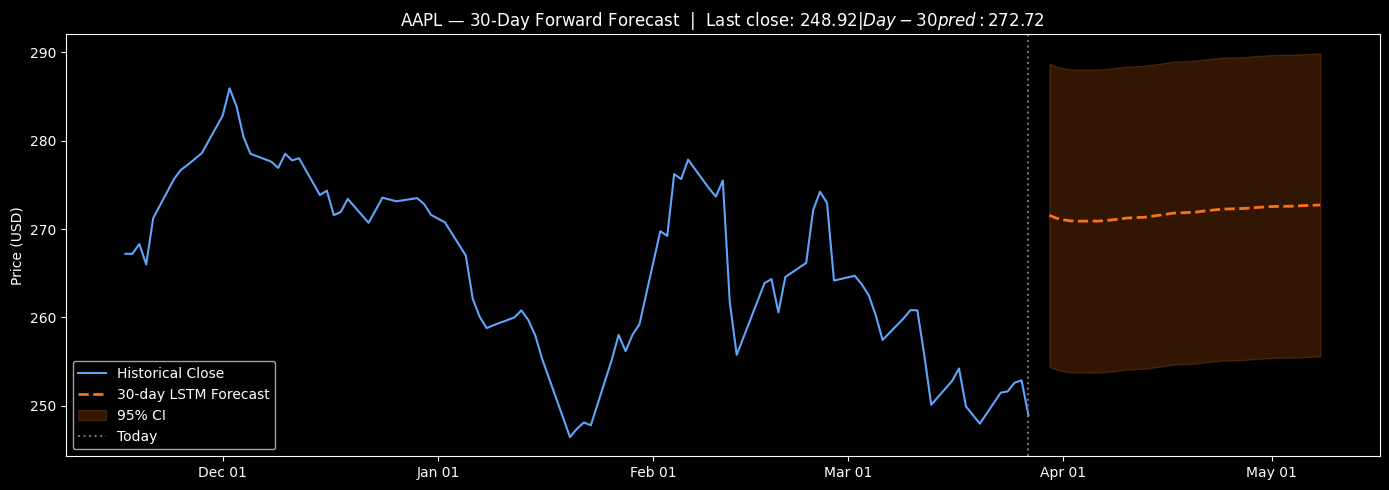


Forecast saved to ../ml-service/saved_models/AAPL/07_30day_forecast.png


In [17]:
# ── Forecast chart ────────────────────────────────────────────────────────────
lookback_days = 90
hist_slice = df['Close'].iloc[-lookback_days:]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(hist_slice.index, hist_slice.values, lw=1.5, color='#60a5fa', label='Historical Close')
ax.plot(forecast_df['date'], forecast_df['price'], lw=2, color='#f97316',
        linestyle='--', label='30-day LSTM Forecast')
ax.fill_between(forecast_df['date'], forecast_df['lower'], forecast_df['upper'],
                alpha=0.2, color='#f97316', label='95% CI')
ax.axvline(df.index[-1], color='#6b7280', lw=1.5, linestyle=':', label='Today')

ax.set_ylabel('Price (USD)')
ax.set_title(f'{TICKER} — 30-Day Forward Forecast  |  Last close: ${hist_slice.iloc[-1]:.2f}  |  Day-30 pred: ${forecast_prices[-1]:.2f}')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/07_30day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nForecast saved to {SAVE_DIR}/07_30day_forecast.png')

## 9 · Summary

In [18]:
print('━' * 55)
print(f'  AAPL LSTM Training Summary')
print('━' * 55)
print(f'  Data:         {len(df)} trading days (2yr OHLCV)')
print(f'  Train/Test:   {len(X_train)}/{len(X_test)} samples (80/20 split)')
print(f'  Seq length:   {SEQ_LEN} days')
print(f'  Architecture: LSTM(50) → Dropout(0.2) → LSTM(50) → Dropout(0.2) → Dense(1)')
print(f'  Parameters:   {model.count_params():,}')
print(f'  Epochs run:   {len(history.history["loss"])}')
print('─' * 55)
print(f'  RMSE:  ${rmse:.4f}')
print(f'  MAE:   ${mae:.4f}')
print(f'  MAPE:  {mape:.4f}%')
print(f'  R²:    {r2:.4f}')
print('─' * 55)
print(f'  Artifacts saved to: {SAVE_DIR}/')
for fname in ['model.h5', 'model.keras', 'scaler.pkl', 'close_scaler.pkl', 'metrics.json']:
    print(f'    ✓ {fname}')
for i in range(1, 8):
    print(f'    ✓ {i:02d}_*.png')
print('━' * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AAPL LSTM Training Summary
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Data:         502 trading days (2yr OHLCV)
  Train/Test:   341/41 samples (80/20 split)
  Seq length:   60 days
  Architecture: LSTM(50) → Dropout(0.2) → LSTM(50) → Dropout(0.2) → Dense(1)
  Parameters:   31,451
  Epochs run:   11
───────────────────────────────────────────────────────
  RMSE:  $16.2353
  MAE:   $14.1906
  MAPE:  5.5215%
  R²:    -2.4388
───────────────────────────────────────────────────────
  Artifacts saved to: ../ml-service/saved_models/AAPL/
    ✓ model.h5
    ✓ model.keras
    ✓ scaler.pkl
    ✓ close_scaler.pkl
    ✓ metrics.json
    ✓ 01_*.png
    ✓ 02_*.png
    ✓ 03_*.png
    ✓ 04_*.png
    ✓ 05_*.png
    ✓ 06_*.png
    ✓ 07_*.png
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
